# 제품 이상여부 판별 프로젝트


## 1. 데이터 불러오기


### 필수 라이브러리


In [1]:
# 간단한 신경망 모델을 만들기 위해 라이브러리 import

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

2024-08-15 03:33:54.527895: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-15 03:33:54.694937: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-15 03:33:56.314345: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2024-08-15 03:33:56.314435: W tensorflow/

In [2]:
# 기본으로 주어진 라이브러리 import cell

import os
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tqdm import tqdm

### 데이터 읽어오기


In [3]:
ROOT_DIR = "data"
RANDOM_STATE = 110

# Load data
train_data = pd.read_csv(os.path.join(ROOT_DIR, "train.csv"))
train_data

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION X Unit Time_Dam,CURE END POSITION X Judge Value_Dam,...,Production Qty Collect Result_Fill2,Production Qty Unit Time_Fill2,Production Qty Judge Value_Fill2,Receip No Collect Result_Fill2,Receip No Unit Time_Fill2,Receip No Judge Value_Fill2,WorkMode Collect Result_Fill2,WorkMode Unit Time_Fill2,WorkMode Judge Value_Fill2,target
0,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,4F1XA938-1,1,OK,240.0,NaN,NaN,...,7,NaN,NaN,127,NaN,NaN,1,NaN,NaN,Normal
1,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,3KPM0016-2,1,OK,240.0,NaN,NaN,...,185,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal
2,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1X9167-1,1,OK,1000.0,NaN,NaN,...,10,NaN,NaN,73,NaN,NaN,1,NaN,NaN,Normal
3,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3K1X0057-1,1,OK,1000.0,NaN,NaN,...,268,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal
4,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3HPM0007-1,1,OK,240.0,NaN,NaN,...,121,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3J1XF434-2,1,OK,240.0,NaN,NaN,...,318,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal
40502,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1XC796-1,1,OK,1000.0,NaN,NaN,...,14,NaN,NaN,197,NaN,NaN,1,NaN,NaN,Normal
40503,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,4C1XD438-1,1,OK,240.0,NaN,NaN,...,1,NaN,NaN,27,NaN,NaN,1,NaN,NaN,Normal
40504,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3I1XA258-1,1,OK,1000.0,NaN,NaN,...,117,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal


In [4]:
train_data.shape

(40506, 464)

In [5]:
train_data.isnull().sum()

Wip Line_Dam                         0
Process Desc._Dam                    0
Equipment_Dam                        0
Model.Suffix_Dam                     0
Workorder_Dam                        0
                                 ...  
Receip No Judge Value_Fill2      40506
WorkMode Collect Result_Fill2        0
WorkMode Unit Time_Fill2         40506
WorkMode Judge Value_Fill2       40506
target                               0
Length: 464, dtype: int64

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40506 entries, 0 to 40505
Columns: 464 entries, Wip Line_Dam to target
dtypes: float64(350), int64(77), object(37)
memory usage: 143.4+ MB


In [7]:
# 결측치가 있는 열 제거
train_data = train_data.dropna(axis=1, how='all')

In [8]:
# 수치형, 범주형 데이터 분리
numeric_columns = train_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = train_data.select_dtypes(exclude=[np.number]).columns.tolist()
categorical_columns.remove('target')  # target 열 제거


# 수치형 데이터의 결측치는 평균값으로 채움
imputer_numeric = SimpleImputer(strategy='mean')
train_data[numeric_columns] = imputer_numeric.fit_transform(train_data[numeric_columns])

# 범주형 데이터의 결측치는 최빈값으로 채움 (이 예제에서는 모든 컬럼이 수치형이므로 여기서는 패스)
if categorical_columns:
    imputer_categorical = SimpleImputer(strategy='most_frequent')
    train_data[categorical_columns] = imputer_categorical.fit_transform(train_data[categorical_columns])
    
#     # 원핫 인코딩도 테스트 해봄
#     # 원핫 인코딩
#     encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
#     encoded_categorical_data = encoder.fit_transform(train_data[categorical_columns])
#     encoded_categorical_df = pd.DataFrame(encoded_categorical_data, columns=encoder.get_feature_names_out(categorical_columns))

#     # 원핫 인코딩한 데이터프레임과 수치형 데이터를 합침
#     train_data = pd.concat([train_data[numeric_columns], encoded_categorical_df, train_data['target']], axis=1)

    # 레이블 인코딩
    encoder = LabelEncoder()
    for col in categorical_columns:
        train_data[col] = encoder.fit_transform(train_data[col])

/tmp/ipykernel_875/346767793.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[numeric_columns] = imputer_numeric.fit_transform(train_data[numeric_columns])
/tmp/ipykernel_875/346767793.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[categorical_columns] = imputer_categorical.fit_transform(train_data[categorical_columns])
/tmp/ipykernel_875/346767793.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

In [9]:
train_data

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,...,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,target
0,0,0,0,3,657,1.0,0,240.0,2.5,-90.0,...,50.0,91.8,270.0,50.0,114.612,19.9,7.0,127.0,1.0,Normal
1,0,0,0,3,283,1.0,0,240.0,2.5,-90.0,...,91.8,270.0,50.0,85.0,19.600,7.0,185.0,1.0,0.0,Normal
2,0,0,1,0,589,1.0,0,1000.0,12.5,90.0,...,50.0,91.8,270.0,50.0,114.612,19.8,10.0,73.0,1.0,Normal
3,0,0,1,0,251,1.0,0,1000.0,12.5,90.0,...,91.8,270.0,50.0,85.0,19.900,12.0,268.0,1.0,0.0,Normal
4,0,0,0,0,142,1.0,0,240.0,2.5,-90.0,...,91.8,270.0,50.0,85.0,19.700,8.0,121.0,1.0,0.0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,0,0,0,0,238,1.0,0,240.0,2.5,-90.0,...,91.8,270.0,50.0,85.0,19.200,1.0,318.0,1.0,0.0,Normal
40502,0,0,1,0,643,1.0,0,1000.0,12.5,90.0,...,50.0,91.8,270.0,50.0,114.612,20.5,14.0,197.0,1.0,Normal
40503,0,0,0,0,540,1.0,0,240.0,2.5,-90.0,...,50.0,91.8,270.0,50.0,85.000,19.7,1.0,27.0,1.0,Normal
40504,0,0,1,0,164,1.0,0,1000.0,12.5,90.0,...,91.8,270.0,50.0,85.0,20.100,13.0,117.0,1.0,0.0,Normal


In [10]:
train_data.isnull().sum()

Wip Line_Dam                           0
Process Desc._Dam                      0
Equipment_Dam                          0
Model.Suffix_Dam                       0
Workorder_Dam                          0
                                      ..
PalletID Collect Result_Fill2          0
Production Qty Collect Result_Fill2    0
Receip No Collect Result_Fill2         0
WorkMode Collect Result_Fill2          0
target                                 0
Length: 186, dtype: int64

### 언더 샘플링


데이타 불균형을 해결하기 위해 언더 샘플링을 진행합니다.


In [11]:
# train_data가 데이터프레임인지 확인하고, 아니라면 데이터프레임으로 변환
if not isinstance(train_data, pd.DataFrame):
    train_data = pd.DataFrame(train_data, columns=[f'feature_{i}' for i in range(train_data.shape[1]-1)] + ['target'])

In [12]:
train_data

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,...,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,target
0,0,0,0,3,657,1.0,0,240.0,2.5,-90.0,...,50.0,91.8,270.0,50.0,114.612,19.9,7.0,127.0,1.0,Normal
1,0,0,0,3,283,1.0,0,240.0,2.5,-90.0,...,91.8,270.0,50.0,85.0,19.600,7.0,185.0,1.0,0.0,Normal
2,0,0,1,0,589,1.0,0,1000.0,12.5,90.0,...,50.0,91.8,270.0,50.0,114.612,19.8,10.0,73.0,1.0,Normal
3,0,0,1,0,251,1.0,0,1000.0,12.5,90.0,...,91.8,270.0,50.0,85.0,19.900,12.0,268.0,1.0,0.0,Normal
4,0,0,0,0,142,1.0,0,240.0,2.5,-90.0,...,91.8,270.0,50.0,85.0,19.700,8.0,121.0,1.0,0.0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,0,0,0,0,238,1.0,0,240.0,2.5,-90.0,...,91.8,270.0,50.0,85.0,19.200,1.0,318.0,1.0,0.0,Normal
40502,0,0,1,0,643,1.0,0,1000.0,12.5,90.0,...,50.0,91.8,270.0,50.0,114.612,20.5,14.0,197.0,1.0,Normal
40503,0,0,0,0,540,1.0,0,240.0,2.5,-90.0,...,50.0,91.8,270.0,50.0,85.000,19.7,1.0,27.0,1.0,Normal
40504,0,0,1,0,164,1.0,0,1000.0,12.5,90.0,...,91.8,270.0,50.0,85.0,20.100,13.0,117.0,1.0,0.0,Normal


In [13]:
normal_ratio = 1.0  # 1.0 means 1:1 ratio

df_normal = train_data[train_data["target"] == "Normal"]
df_abnormal = train_data[train_data["target"] == "AbNormal"]

num_normal = len(df_normal)
num_abnormal = len(df_abnormal)
print(f"  Total: Normal: {num_normal}, AbNormal: {num_abnormal}")

df_normal = df_normal.sample(n=int(num_abnormal * normal_ratio), replace=False, random_state=RANDOM_STATE)
df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
df_concat.value_counts("target")

  Total: Normal: 38156, AbNormal: 2350


target
AbNormal    2350
Normal      2350
Name: count, dtype: int64

### 데이터 분할


In [14]:
df_train, df_val = train_test_split(
    df_concat,
    test_size=0.3,
    stratify=df_concat["target"],
    random_state=RANDOM_STATE,
)


def print_stats(df: pd.DataFrame):
    num_normal = len(df[df["target"] == "Normal"])
    num_abnormal = len(df[df["target"] == "AbNormal"])

    print(f"  Total: Normal: {num_normal}, AbNormal: {num_abnormal}" + f" ratio: {num_abnormal/num_normal}")


# Print statistics
print(f"  \tAbnormal\tNormal")
print_stats(df_train)
print_stats(df_val)

  	Abnormal	Normal
  Total: Normal: 1645, AbNormal: 1645 ratio: 1.0
  Total: Normal: 705, AbNormal: 705 ratio: 1.0


## 3. 모델 학습


### 모델 정의


In [15]:
# model = RandomForestClassifier(random_state=RANDOM_STATE)

In [16]:
# train, val 세트 나누기

train_y = df_train["target"]
train_x = df_train.drop("target", axis=1)

val_y = df_val["target"]
val_x = df_val.drop('target', axis=1)

In [17]:
# feature 데이터 정규화
scaler = StandardScaler()
train_x = scaler.fit_transform(train_x)
val_x = scaler.transform(val_x)

In [18]:
# target 라벨링 (Normal: 0, AbNormal: 1)
label_encoder = LabelEncoder()
train_y = label_encoder.fit_transform(train_y)
val_y = label_encoder.transform(val_y)

In [19]:
model = Sequential([
    Dense(256, input_shape=(train_x.shape[1],), activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # 이진 분류이므로 sigmoid activation 사용
])

2024-08-15 03:34:03.973486: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2024-08-15 03:34:03.973516: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)


In [20]:
# 모델 컴파일
model.compile(optimizer=Adam(learning_rate=0.005), loss='binary_crossentropy', metrics=['accuracy'])

### 모델 학습


In [21]:
history = model.fit(train_x, train_y, epochs=50, batch_size=32, validation_data=(val_x, val_y))

Epoch 1/50
103/103 [==============================] - 2s 4ms/step - loss: 0.7591 - accuracy: 0.5316 - val_loss: 0.7543 - val_accuracy: 0.5610
Epoch 2/50
103/103 [==============================] - 0s 3ms/step - loss: 0.6972 - accuracy: 0.5450 - val_loss: 0.6963 - val_accuracy: 0.5135
Epoch 3/50
103/103 [==============================] - 0s 3ms/step - loss: 0.6938 - accuracy: 0.5456 - val_loss: 0.6811 - val_accuracy: 0.5645
Epoch 4/50
103/103 [==============================] - 0s 3ms/step - loss: 0.6837 - accuracy: 0.5751 - val_loss: 0.6830 - val_accuracy: 0.5745
Epoch 5/50
103/103 [==============================] - 0s 3ms/step - loss: 0.6826 - accuracy: 0.5693 - val_loss: 0.6879 - val_accuracy: 0.5667
Epoch 6/50
103/103 [==============================] - 0s 3ms/step - loss: 0.6803 - accuracy: 0.5839 - val_loss: 0.6939 - val_accuracy: 0.5752
Epoch 7/50
103/103 [==============================] - 0s 3ms/step - loss: 0.6793 - accuracy: 0.5726 - val_loss: 0.6802 - val_accuracy: 0.5702
Epoch 

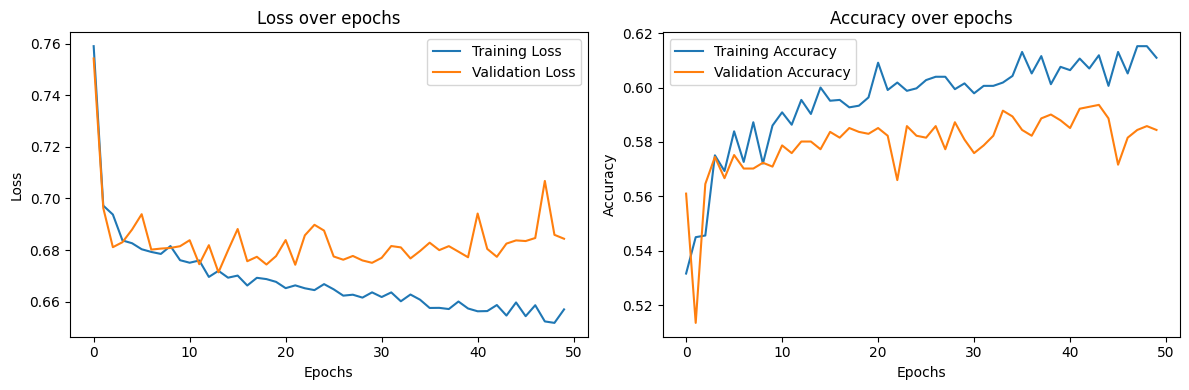

In [22]:
import matplotlib.pyplot as plt

# 손실 그래프 그리기
plt.figure(figsize=(12, 4))

# 손실 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 정확도 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 그래프 보여주기
plt.tight_layout()
plt.show()


In [23]:
# features = []

# for col in df_train.columns:
#     try:
#         df_train[col] = df_train[col].astype(int)
#         features.append(col)
#     except:
#         continue

# train_x = df_train[features]
# train_y = df_train["target"]

# model.fit(train_x, train_y)

## 4. 제출하기


### 테스트 데이터 예측


테스트 데이터 불러오기


In [47]:
test_data = pd.read_csv(os.path.join(ROOT_DIR, "test.csv"))

In [48]:
test_data["target"]

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
17356   NaN
17357   NaN
17358   NaN
17359   NaN
17360   NaN
Name: target, Length: 17361, dtype: float64

In [49]:
# 결측치가 있는 열 제거
test_data = test_data.dropna(axis=1, how='all')

In [50]:
test_data = test_data.drop("Set ID", axis=1)

In [51]:
# 수치형, 범주형 데이터 분리
numeric_columns = test_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = test_data.select_dtypes(exclude=[np.number]).columns.tolist()


# 수치형 데이터의 결측치는 평균값으로 채움
imputer_numeric = SimpleImputer(strategy='mean')
test_data[numeric_columns] = imputer_numeric.fit_transform(test_data[numeric_columns])

# 범주형 데이터의 결측치는 최빈값으로 채움 (이 예제에서는 모든 컬럼이 수치형이므로 여기서는 패스)
if categorical_columns:
    imputer_categorical = SimpleImputer(strategy='most_frequent')
    test_data[categorical_columns] = imputer_categorical.fit_transform(test_data[categorical_columns])
    
#     # 원핫 인코딩도 테스트 해봄
#     # 원핫 인코딩
#     encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
#     encoded_categorical_data = encoder.fit_transform(train_data[categorical_columns])
#     encoded_categorical_df = pd.DataFrame(encoded_categorical_data, columns=encoder.get_feature_names_out(categorical_columns))

#     # 원핫 인코딩한 데이터프레임과 수치형 데이터를 합침
#     train_data = pd.concat([train_data[numeric_columns], encoded_categorical_df, train_data['target']], axis=1)

    # 레이블 인코딩
    encoder = LabelEncoder()
    for col in categorical_columns:
        test_data[col] = encoder.fit_transform(test_data[col])

In [52]:
test_data

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,...,Head Clean Position Y Collect Result_Fill2,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2
0,0,0,1,0,240,1.0,0,1000.0,12.5,90.0,...,50.0,91.8,270.0,50.0,85.0,19.8,13.0,195.0,1.0,0.0
1,0,0,1,0,509,1.0,0,1000.0,12.5,90.0,...,119.0,50.0,91.8,270.0,50.0,85.0,19.8,14.0,256.0,1.0
2,0,0,0,0,128,1.0,0,240.0,2.5,-90.0,...,50.0,91.8,270.0,50.0,85.0,19.7,1.0,98.0,1.0,0.0
3,0,0,1,0,306,1.0,0,1000.0,12.5,90.0,...,119.0,50.0,91.8,270.0,50.0,85.0,20.0,14.0,0.0,1.0
4,0,0,0,0,415,1.0,0,240.0,2.5,-90.0,...,119.0,50.0,91.8,270.0,50.0,85.0,19.8,1.0,215.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17356,0,0,1,0,277,1.0,0,1000.0,12.5,90.0,...,119.0,50.0,91.8,270.0,50.0,85.0,19.5,14.0,131.0,1.0
17357,0,0,1,0,439,1.0,0,1000.0,12.5,90.0,...,119.0,50.0,91.8,270.0,50.0,85.0,19.8,12.0,279.0,1.0
17358,0,0,0,0,314,1.0,0,240.0,2.5,-90.0,...,119.0,50.0,91.8,270.0,50.0,85.0,20.5,4.0,66.0,1.0
17359,0,0,0,0,8,1.0,0,240.0,2.5,-90.0,...,50.0,91.8,270.0,50.0,85.0,18.9,1.0,117.0,1.0,0.0


In [53]:
test_data = scaler.transform(test_data)

In [ ]:
# df_test_x = test_data[features]

# for col in df_test_x.columns:
#     try:
#         df_test_x.loc[:, col] = df_test_x[col].astype(int)
#     except:
#         continue

In [66]:
test_pred = model.predict(test_data)
test_pred

543/543 [==============================] - 1s 2ms/step


array([[0.4073978 ],
       [0.69418687],
       [0.469296  ],
       ...,
       [0.59675944],
       [0.43816894],
       [0.5286854 ]], dtype=float32)

In [71]:
test_pred = (test_pred >= 0.5).astype(int)  # 0.5 이상은 1, 미만은 0으로 변환
test_pred = ['Normal' if pred == 1 else 'AbNormal' for pred in test_pred]
test_pred

['AbNormal',
 'Normal',
 'AbNormal',
 'Normal',
 'Normal',
 'AbNormal',
 'AbNormal',
 'AbNormal',
 'AbNormal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'AbNormal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'AbNormal',
 'AbNormal',
 'AbNormal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'AbNormal',
 'AbNormal',
 'Normal',
 'AbNormal',
 'Normal',
 'Normal',
 'Normal',
 'AbNormal',
 'AbNormal',
 'AbNormal',
 'AbNormal',
 'Normal',
 'AbNormal',
 'Normal',
 'AbNormal',
 'AbNormal',
 'Normal',
 'Normal',
 'AbNormal',
 'Normal',
 'AbNormal',
 'Normal',
 'AbNormal',
 'Normal',
 'Normal',
 'AbNormal',
 'AbNormal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'AbNormal',
 'AbNormal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'AbNormal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'AbNormal',
 'AbNormal',
 'AbNormal',
 'AbNormal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 

### 제출 파일 작성


In [72]:
# 제출 데이터 읽어오기 (df_test는 전처리된 데이터가 저장됨)
df_sub = pd.read_csv("submission.csv")
df_sub["target"] = test_pred

# 제출 파일 저장
df_sub.to_csv("submission.csv", index=False)

**우측 상단의 제출 버튼을 클릭해 결과를 확인하세요**
